<a href="https://colab.research.google.com/github/Mauricio-Fragoso-Mendoza/Simulacion-I/blob/main/L%C3%ADnea_de_Espera_con_un_Servidor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import random as r
import math as m
import matplotlib.pyplot as plt

Los elementos a destacar son:

$t$: Tiempo

$N_A$: Número de llegadas

$N_D$: Número de salidas

Eventos:

$t_A$: Tiempo de la siguiente llegada

$t_D$: Tiempo de la siguiente salida

Queremos:

a) Tiempo promedio de un cliente en el sistema

b) Tiempo en que sale el último cliente

Generar $T_0 \rightarrow U \backsim U(0,1)$
$$t=t-\frac{1}{\lambda}\log U$$
$$t_A=T_0$$
$$t_D=\infty$$

In [24]:
def SLE(lam, T):
  t=0
  S=[]
  NA=0
  A=[]
  ND=0
  D=[]
  Tp=[]
  while T>=t:
    T0=r.random()
    t = t-((1/lam)*np.log(T0))
    n=0
    tA=T0
    tD=m.inf
    if tA<=tD and tA<=T:
      t=tA
      NA=NA+1
      n=n+1
      Ti=r.random()
      tA=Ti
      if n==1:
        Y=r.random()
        tD=t+Y
      S.append(t)
    elif tD<tA and tD<=T:
      t=tD
      ND=ND+1
      n=n-1
      if n==0:
        tD=m.inf
      else:
        Y=r.random()
        tD=t+Y
      A.append(tD)
    elif min(tA,tD)>T and n>0:
      t=tD
      ND=ND+1
      n=n-1
      if n>0:
        Y=r.random()
        tD=t+Y
      D.append(tD)
    elif min(tA,tD)>T and n==0:
      tp=max(t-T,0)
      Tp.append(tp)
  return S,A,D,Tp

Para este caso se usará: $\lambda = 4$ y $\mu = 6 \Rightarrow T = \frac{1}{6}$

In [25]:
Z=SLE(4,1/6)

In [26]:
Z

([0.08362529842726729], [], [], [0, np.float64(0.10126831756284424)])

Otra forma de atacar el problema es evaluando la estabilidad del sistema

Se tiene un modelo para líneas de espera con un servidor ($M/M/1$) con:

Tasa de llegadas: $\lambda = \frac{1}{\bar{x}_{inter}}$; con $\bar{x}_{inter}$: Promedio de interarribos de los clientes

Tasa de servicio: $\mu = \frac{1}{\bar{x}_{TS}}$; con $\bar{x}_{TS}$: Promedio del tiempo de servicio

Estabilidad del sistema: $\rho = \frac{\lambda}{\mu}$

Si $\rho < 1$: el sistema funciona bien

$\rho_n = \rho^n \rho_0$, $n=0,1,2,...$

$\rho_0 (1+\rho+\rho^2+...)=1$

$\rho_0 = 1-\rho$

$\rho_0 = 1-\rho$ siempre y cuando $\rho < 1$

$\rho_n=(1-\rho)\rho^n$, con $n=1,2,...$

Si $\rho \geq 1$ el sistema colapsa

Posteriormente se tendrán las siguientes ecuaciones para la medida del desempeño:
$$L_S = \frac{\rho}{1-\rho}$$
$$W_S = \frac{L_S}{\lambda} = \frac{1}{\mu - \lambda}$$
$$W_q = W_S - \frac{1}{\mu} = \frac{\rho}{\mu (1 - \rho)}$$
$$L_q = \lambda W_q = \frac{\rho^2}{1-\rho}$$
$$\bar{c} = L_S - L_q = \rho$$

In [36]:
def LE1S(lambda_val,mu,n):
  rho=lambda_val/mu
  s=[]
  if rho < 1:
    for i in range(n):
      rho=rho
      LS=rho/(1-rho)
      WS=1/(mu-lambda_val)
      WQ=WS-1/mu
      LQ=rho**2/(1-rho)
      c=LS-LQ
      rho0=1-rho
      rhon=(rho**n)*(rho0)
      rho=rho+rhon
      s.append([LS,WS,WQ,LQ,c,rho])
  return s

In [37]:
Z=LE1S(4,6,12)

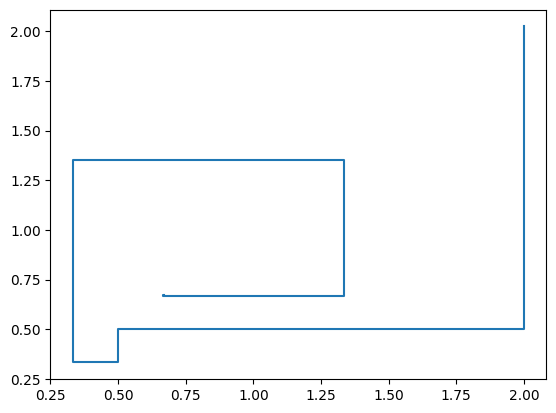

In [38]:
plt.step(Z[0],Z[1])